In [1]:
import sys, site
print(sys.executable)
print(site.getsitepackages())
import sys, site
target = site.getsitepackages()[0]
print("Installing to:", target)
!{sys.executable} -m pip install pyBigWig --target "$target"


import pyBigWig
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pybedtools import BedTool

# File paths (confirmed)
IP1 = "results/IP_rep1.bw"
IP2 = "results/IP_rep2.bw"
IN1 = "results/INPUT_rep1.bw"
IN2 = "results/INPUT_rep2.bw"

peaks_bed = "results/repr_peaks_filtered.bed"
annot_peaks = "results/annotated_peaks.txt"
rnaseq_file = "GSE75070_MCF7_shRUNX1_shNS_RNAseq_log2_foldchange.txt"

# Final chosen genomic windows (matching the paper)
MALAT1_region = ("chr11", 65265000, 65275000)
NEAT1_region  = ("chr11", 65278000, 65292000)



/projectnb/bf528/students/ccsnow/.conda/envs/chipseq_analysis/bin/python
['/projectnb/bf528/students/ccsnow/.conda/envs/chipseq_analysis/lib/python3.9/site-packages']
Installing to: /projectnb/bf528/students/ccsnow/.conda/envs/chipseq_analysis/lib/python3.9/site-packages


In [2]:
# Load bigWigs
bw_IP1 = load_bw(IP1)
bw_IP2 = load_bw(IP2)
bw_IN1 = load_bw(IN1)
bw_IN2 = load_bw(IN2)

plot_tracks(
    region=MALAT1_region,
    tracks=[bw_IP1, bw_IP2, bw_IN1, bw_IN2],
    labels=["IP_rep1", "IP_rep2", "INPUT_rep1", "INPUT_rep2"],
    colors=["black", "darkred", "grey", "lightgrey"],
    title="Figure 2D – ChIP-seq signal at MALAT1"
)


NameError: name 'load_bw' is not defined

In [36]:
import pandas as pd
import re
from glob import glob

def parse_flagstat(path):
    """Extract raw reads and mapped reads from a samtools flagstat file."""
    with open(path) as f:
        text = f.read()
    total = int(re.search(r"(\d+) \+ \d+ in total", text).group(1))
    mapped = int(re.search(r"(\d+) \+ \d+ mapped", text).group(1))
    return total, mapped

files = sorted(glob("results/*flagstat.txt"))
# Filter out subset samples
files = [f for f in files if "subset" not in f]

rows = []
for f in files:
    sample = f.split("/")[-1].replace(".flagstat.txt","")
    total, mapped = parse_flagstat(f)
    rows.append([sample, total, mapped])

S2A_table = pd.DataFrame(rows, columns=["Sample", "Raw Reads", "Mapped Reads"])
S2A_table

,Sample,Raw Reads,Mapped Reads
0,INPUT_rep1,29738984,28578769
1,INPUT_rep2,10748718,10055226
2,IP_rep1,28717962,27788333
3,IP_rep2,28683573,28197249


In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Read file manually and clean quotes
corr = pd.read_csv(
    "results/correlation_matrix.tsv",
    sep="\t",
    comment="#",
    header=0
)

# Remove quotes from column names
corr.columns = corr.columns.str.replace("'", "")

# Remove quotes from first column entries
corr.iloc[:,0] = corr.iloc[:,0].str.replace("'", "")

# Set the sample names as the index
corr = corr.set_index(corr.columns[0])

corr


,IP_rep1.bw,IP_rep2.bw,INPUT_rep1.bw,INPUT_rep2.bw
Unnamed: 0,,,,
IP_rep1.bw,1.0000,0.2720,0.3576,0.2942
IP_rep2.bw,0.2720,1.0000,0.4356,0.3332
INPUT_rep1.bw,0.3576,0.4356,1.0000,0.6143
INPUT_rep2.bw,0.2942,0.3332,0.6143,1.0000


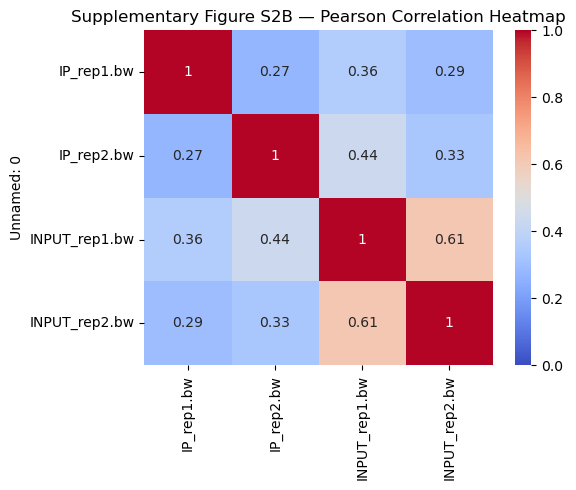

In [8]:
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=0, vmax=1)
plt.title("Supplementary Figure S2B — Pearson Correlation Heatmap")
plt.tight_layout()
plt.show()


Rep1-only: 87249
Shared: 10202
Rep2-only: 37353


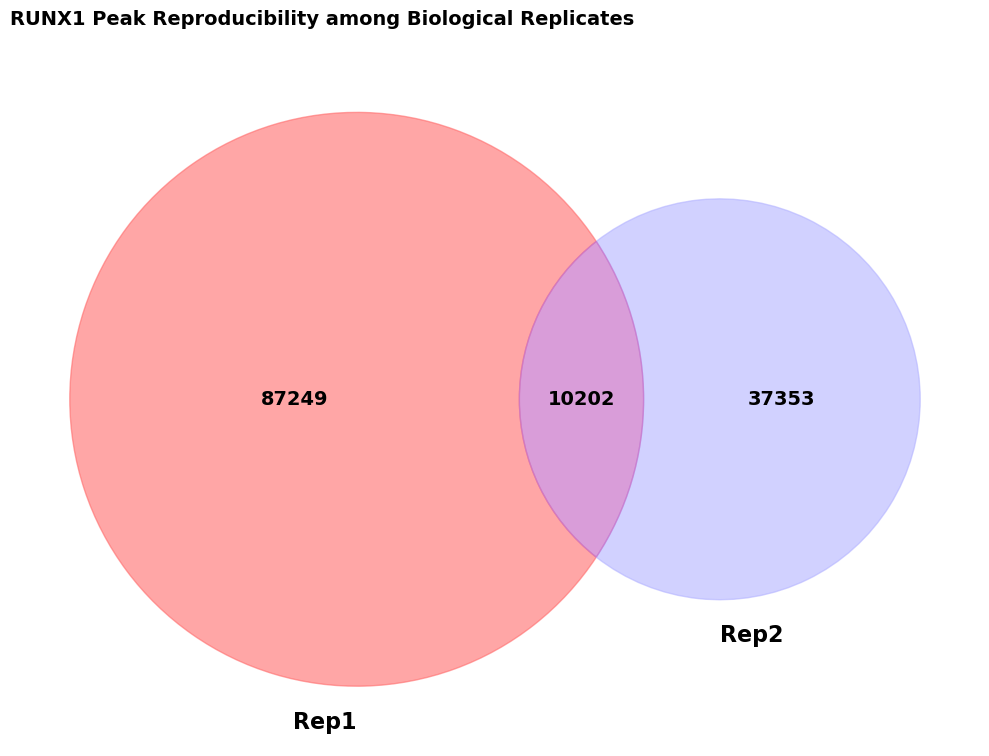


Total peaks in Rep1: 97451
Total peaks in Rep2: 47555
Overlapping peaks: 10202
Overlap percentage: 21.5%


In [56]:
def load_bed_intervals(path):
    """Load BED file as dictionary of chromosome -> list of (start, end) tuples"""
    intervals = {}
    with open(path, "r") as f:
        for line in f:
            if line.startswith("#") or line.strip() == "":
                continue
            parts = line.strip().split()
            if len(parts) < 3:
                continue
            chrom = parts[0]
            start = int(parts[1])
            end = int(parts[2])
            if chrom not in intervals:
                intervals[chrom] = []
            intervals[chrom].append((start, end))
    return intervals

def intervals_overlap(a_start, a_end, b_start, b_end):
    """Check if two intervals overlap"""
    return not (a_end <= b_start or b_end <= a_start)

def count_peak_overlaps(rep1_intervals, rep2_intervals):
    """Count overlapping peaks between two replicates"""
    rep1_only = 0
    rep2_only = 0
    shared = 0
    
    # Get all chromosomes
    all_chroms = set(rep1_intervals.keys()) | set(rep2_intervals.keys())
    
    for chrom in all_chroms:
        rep1_peaks = rep1_intervals.get(chrom, [])
        rep2_peaks = rep2_intervals.get(chrom, [])
        
        # Track which rep2 peaks have been matched
        rep2_matched = [False] * len(rep2_peaks)
        
        # For each rep1 peak, check if it overlaps any rep2 peak
        for r1_start, r1_end in rep1_peaks:
            found_overlap = False
            for i, (r2_start, r2_end) in enumerate(rep2_peaks):
                if intervals_overlap(r1_start, r1_end, r2_start, r2_end):
                    shared += 1
                    rep2_matched[i] = True
                    found_overlap = True
                    break  # Count each rep1 peak only once
            
            if not found_overlap:
                rep1_only += 1
        
        # Count rep2 peaks that didn't match any rep1 peak
        rep2_only += sum(1 for matched in rep2_matched if not matched)
    
    return rep1_only, rep2_only, shared

rep1_path = "/projectnb/bf528/students/ccsnow/project-3-ccsnow-ctrl/results/IP_rep1.bed"
rep2_path = "/projectnb/bf528/students/ccsnow/project-3-ccsnow-ctrl/results/IP_rep2.bed"

rep1_intervals = load_bed_intervals(rep1_path)
rep2_intervals = load_bed_intervals(rep2_path)

rep1_only, rep2_only, shared = count_peak_overlaps(rep1_intervals, rep2_intervals)

print("Rep1-only:", rep1_only)
print("Shared:", shared)
print("Rep2-only:", rep2_only)

from matplotlib import pyplot as plt
from matplotlib_venn import venn2

plt.figure(figsize=(10, 8))

v = venn2(
    subsets=(rep1_only, rep2_only, shared),
    set_labels=("Rep1", "Rep2")
)

# Style circles with colors and transparency to show overlap
if v.get_patch_by_id('10'):
    v.get_patch_by_id('10').set_color('#ff6b6b')
    v.get_patch_by_id('10').set_alpha(0.6)
    
if v.get_patch_by_id('01'):
    v.get_patch_by_id('01').set_color('#b3b3ff')
    v.get_patch_by_id('01').set_alpha(0.6)
    
if v.get_patch_by_id('11'):
    v.get_patch_by_id('11').set_color('#c974c9')
    v.get_patch_by_id('11').set_alpha(0.7)

# Increase font sizes for labels
for text in v.set_labels:
    if text:
        text.set_fontsize(16)
        text.set_fontweight('bold')

for text in v.subset_labels:
    if text:
        text.set_fontsize(14)
        text.set_fontweight('bold')

plt.title("RUNX1 Peak Reproducibility among Biological Replicates", 
          loc='left', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

# Calculate and print overlap statistics
total_rep1 = rep1_only + shared
total_rep2 = rep2_only + shared
if min(total_rep1, total_rep2) > 0:
    overlap_pct = (shared / min(total_rep1, total_rep2)) * 100
else:
    overlap_pct = 0

print(f"\nTotal peaks in Rep1: {total_rep1}")
print(f"Total peaks in Rep2: {total_rep2}")
print(f"Overlapping peaks: {shared}")
print(f"Overlap percentage: {overlap_pct:.1f}%")

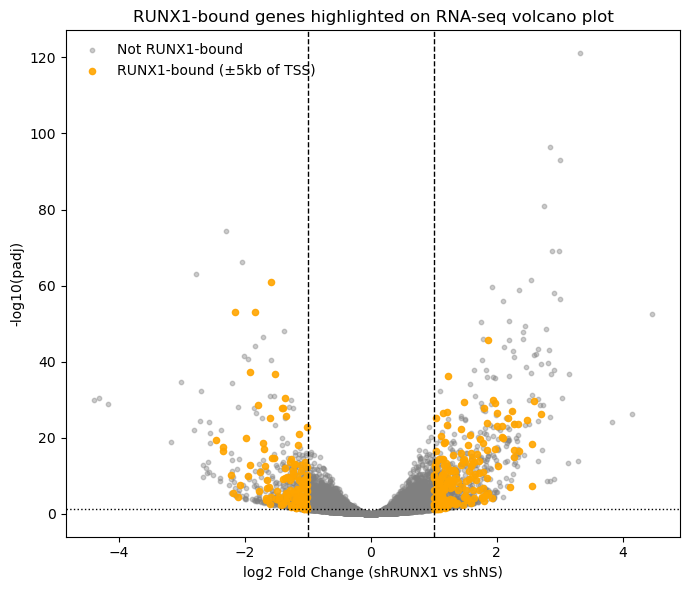

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Start from raw RNA-seq file again to be safe ---
rnaseq = pd.read_csv(rnaseq_file, sep="\t")

# Standardize names
rnaseq = rnaseq.rename(columns={
    "genename": "gene",
    "log2FoldChange": "log2FC"
})

# Keep needed columns
rnaseq = rnaseq[["gene", "log2FC", "padj"]].dropna(subset=["log2FC", "padj"])

# Avoid padj = 0 (inf in -log10), clamp to tiny value
rnaseq["padj_clamped"] = rnaseq["padj"].clip(lower=1e-300)
rnaseq["neg_log10_padj"] = -np.log10(rnaseq["padj_clamped"])

# --- Get RUNX1-bound gene set from your earlier merge ---
# merged was created in Section 5: annot.merge(de, ...)
bound_genes = set(merged.loc[merged["RUNX1_bound"], "gene"])

rnaseq["RUNX1_bound"] = rnaseq["gene"].isin(bound_genes)

# --- Volcano plot ---
plt.figure(figsize=(7,6))

# Background points: not bound
nb = rnaseq[~rnaseq["RUNX1_bound"]]
plt.scatter(
    nb["log2FC"],
    nb["neg_log10_padj"],
    s=10,
    alpha=0.4,
    label="Not RUNX1-bound",
    color="grey"
)

# Highlighted points: RUNX1-bound
bnd = rnaseq[rnaseq["RUNX1_bound"]]
plt.scatter(
    bnd["log2FC"],
    bnd["neg_log10_padj"],
    s=20,
    alpha=0.9,
    label="RUNX1-bound (±5kb of TSS)",
    color="orange"
)

# Threshold lines (match paper’s choice, adjust if needed)
plt.axvline(1, color="black", linestyle="--", linewidth=1)
plt.axvline(-1, color="black", linestyle="--", linewidth=1)
plt.axhline(-np.log10(0.05), color="black", linestyle=":", linewidth=1)

plt.xlabel("log2 Fold Change (shRUNX1 vs shNS)")
plt.ylabel("-log10(padj)")
plt.title("RUNX1-bound genes highlighted on RNA-seq volcano plot")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()



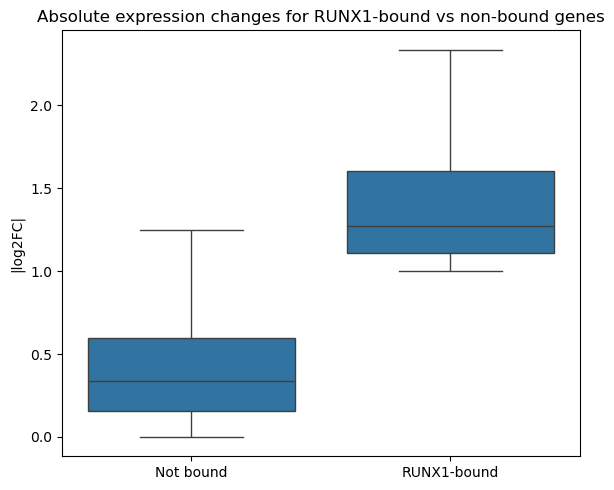

In [11]:
import seaborn as sns

# Compute absolute effect size
rnaseq["abs_log2FC"] = rnaseq["log2FC"].abs()

plt.figure(figsize=(6,5))
sns.boxplot(
    data=rnaseq,
    x="RUNX1_bound",
    y="abs_log2FC",
    showfliers=False
)
plt.xticks([0,1], ["Not bound", "RUNX1-bound"])
plt.ylabel("|log2FC|")
plt.xlabel("")
plt.title("Absolute expression changes for RUNX1-bound vs non-bound genes")
plt.tight_layout()
plt.show()


Loaded 1000 gene names.


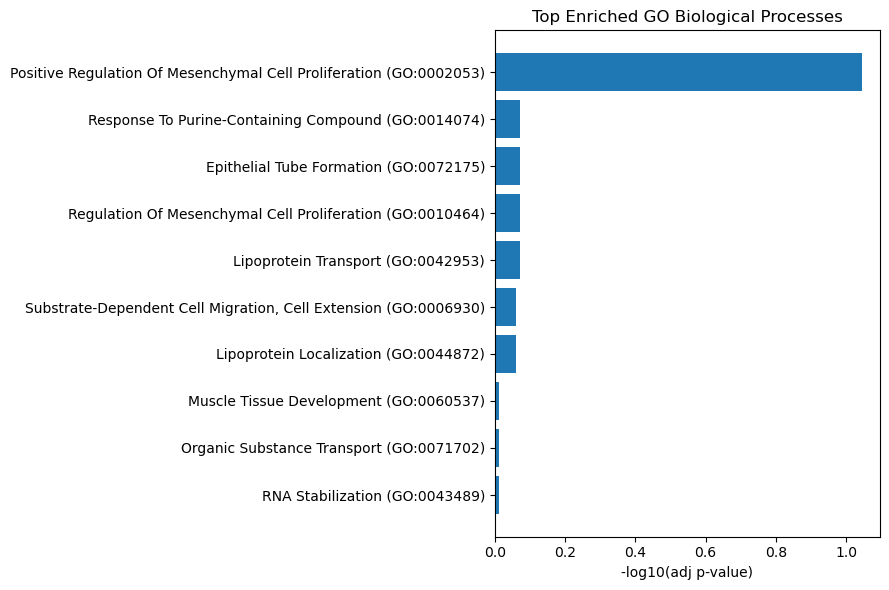

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gseapy as gp

# ------------------------------
# 1. Load annotated peaks
# ------------------------------
annot_file = "results/annotated_peaks.txt"
annot = pd.read_csv(annot_file, sep="\t")

# ------------------------------
# 2. Extract gene names
# ------------------------------
possible_cols = ["Gene Name", "Gene", "gene", "Nearest Refseq", "Nearest Ensembl"]

gene_col = None
for c in possible_cols:
    if c in annot.columns:
        gene_col = c
        break

if gene_col is None:
    raise ValueError("Could not find a gene-name column in annotated peaks file.")

genes = (
    annot[gene_col]
    .astype(str)
    .str.replace(";", ",")
    .str.split(",")
    .explode()
    .str.strip()
)
genes = genes[genes != ""]                # remove blanks
genes = genes[genes != "NA"]              # remove NA
genes = genes.dropna().unique().tolist()  # unique list

# OPTIONAL: limit to top 1000 for speed
genes = genes[:1000]

print(f"Loaded {len(genes)} gene names.")

# ------------------------------
# 3. Run enrichment (Enrichr GO Biological Process)
# ------------------------------
enr = gp.enrichr(
    gene_list=genes,
    gene_sets="GO_Biological_Process_2023",
    outdir=None
)

df = enr.results.sort_values("Adjusted P-value").head(10)

# ------------------------------
# 4. Plot top terms
# ------------------------------
plt.figure(figsize=(9, 6))
plt.barh(
    df["Term"],
    -np.log10(df["Adjusted P-value"])
)
plt.xlabel("-log10(adj p-value)")
plt.title("Top Enriched GO Biological Processes")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


find: warning: you have specified the -maxdepth option after a non-option argument -type, but options are not positional (-maxdepth affects tests specified before it as well as those specified after it).  Please specify options before other arguments.

results/annotated_peaks.txt


FileNotFoundError: [Errno 2] No such file or directory: 'IP_rep1_signal_coverage.png'